<a href="https://colab.research.google.com/github/AceRb6/Modelos_Econometricos/blob/main/PME07_Modelos_de_rezago_distribuido.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Descarga y carga del dataset
url = "https://www.statlearning.com/s/Advertising.csv"
df = pd.read_csv(url)

# Eliminación de columna índice si existe (común en este dataset)
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)

# Visualización inicial
print(df.head())
print(df.info())
print(df.describe())

      TV  radio  newspaper  sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3    9.3
3  151.5   41.3       58.5   18.5
4  180.8   10.8       58.4   12.9
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None
               TV       radio   newspaper       sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   14.022500
std     85.854236   14.846809   21.778621    5.217457
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   10.375000
50%    149.750000   22.900000   25.750000   12.900000
75%    218.825000   36.525000

Matriz de Correlación:
                 TV     radio  newspaper     sales
TV         1.000000  0.054809   0.056648  0.782224
radio      0.054809  1.000000   0.354104  0.576223
newspaper  0.056648  0.354104   1.000000  0.228299
sales      0.782224  0.576223   0.228299  1.000000


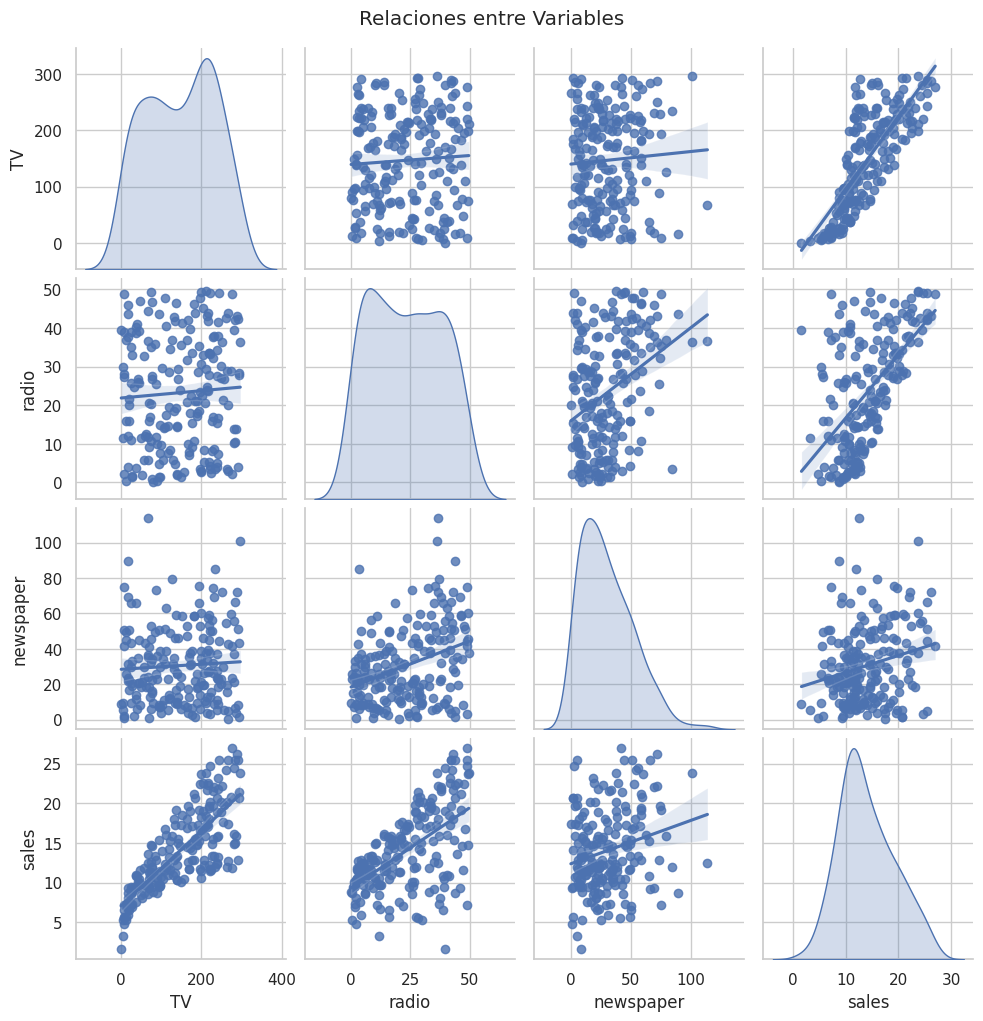

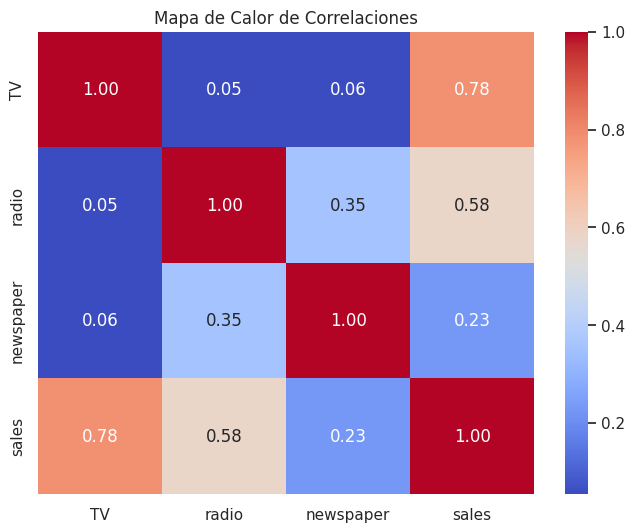

In [ ]:
# Análisis de correlaciones
corr_matrix = df.corr()
print("Matriz de Correlación:")
print(corr_matrix)

# Visualización de relaciones
sns.pairplot(df, kind='reg', diag_kind='kde')
plt.suptitle("Relaciones entre Variables", y=1.02)
plt.show()

# Heatmap de correlación
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Mapa de Calor de Correlaciones")
plt.show()

In [ ]:
import statsmodels.api as sm

# Definición de variables
X = df[['TV', 'radio', 'newspaper']]
y = df['sales']

# Adición de constante (intercepto)
X_with_const = sm.add_constant(X)

# Ajuste del modelo OLS
model_base = sm.OLS(y, X_with_const).fit()

# Resumen de resultados
print(model_base.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Mon, 18 May 2026   Prob (F-statistic):           1.58e-96
Time:                        05:22:40   Log-Likelihood:                -386.18
No. Observations:                 200   AIC:                             780.4
Df Residuals:                     196   BIC:                             793.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9389      0.312      9.422      0.0

In [ ]:
# Creación de variables rezagadas (simulación de serie temporal para el ejercicio)
# Nota: El dataset original es cross-sectional. Para aplicar rezagos distribuidos como pide la práctica,
# asumiremos un orden temporal implícito o reordenaremos por una variable proxy si fuera necesario.
# Dado que es Advertising Dataset estándar, usualmente se trata como cross-sectional.
# Sin embargo, la práctica pide "Modelos de rezago distribuido".
# Estrategia: Asumir que las observaciones están ordenadas temporalmente (índice 0 a 199).

df_sorted = df.sort_index().reset_index(drop=True)

# Generar rezagos de orden 1 para TV, Radio y Newspaper
# Shift(1) mueve los datos hacia abajo, alineando el periodo t-1 con el t.
df_sorted['TV_lag1'] = df_sorted['TV'].shift(1)
df_sorted['radio_lag1'] = df_sorted['radio'].shift(1)
df_sorted['newspaper_lag1'] = df_sorted['newspaper'].shift(1)

# Eliminar la primera fila que tendrá NaNs debido al rezago
df_model = df_sorted.dropna().reset_index(drop=True)

print(df_model.head())
print(f"Observaciones disponibles tras aplicar rezago: {len(df_model)}")

      TV  radio  newspaper  sales  TV_lag1  radio_lag1  newspaper_lag1
0   44.5   39.3       45.1   10.4    230.1        37.8            69.2
1   17.2   45.9       69.3    9.3     44.5        39.3            45.1
2  151.5   41.3       58.5   18.5     17.2        45.9            69.3
3  180.8   10.8       58.4   12.9    151.5        41.3            58.5
4    8.7   48.9       75.0    7.2    180.8        10.8            58.4
Observaciones disponibles tras aplicar rezago: 199


In [ ]:
# Definición de variables para el modelo de rezagos distribuidos
X_dynamic = df_model[['TV', 'radio', 'newspaper', 'TV_lag1', 'radio_lag1', 'newspaper_lag1']]
y_dynamic = df_model['sales']

# Adición de constante
X_dynamic_const = sm.add_constant(X_dynamic)

# Ajuste del modelo dinámico
model_dynamic = sm.OLS(y_dynamic, X_dynamic_const).fit()

# Resumen de resultados
print(model_dynamic.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.898
Model:                            OLS   Adj. R-squared:                  0.895
Method:                 Least Squares   F-statistic:                     282.6
Date:                Mon, 18 May 2026   Prob (F-statistic):           1.98e-92
Time:                        05:23:15   Log-Likelihood:                -382.50
No. Observations:                 199   AIC:                             779.0
Df Residuals:                     192   BIC:                             802.0
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              3.0106      0.426      7.

--- COMPARACIÓN DE MODELOS ---
Modelo Base R-squared: 0.8972
Modelo Dinámico R-squared: 0.8983
Modelo Base Adj. R-squared: 0.8956
Modelo Dinámico Adj. R-squared: 0.8951
Modelo Base AIC: 780.36
Modelo Dinámico AIC: 779.00


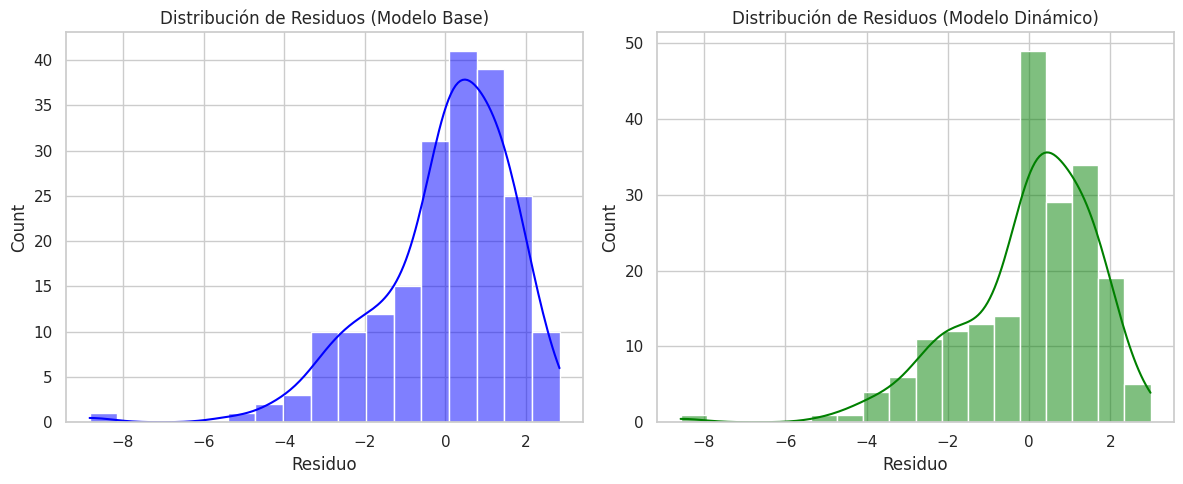

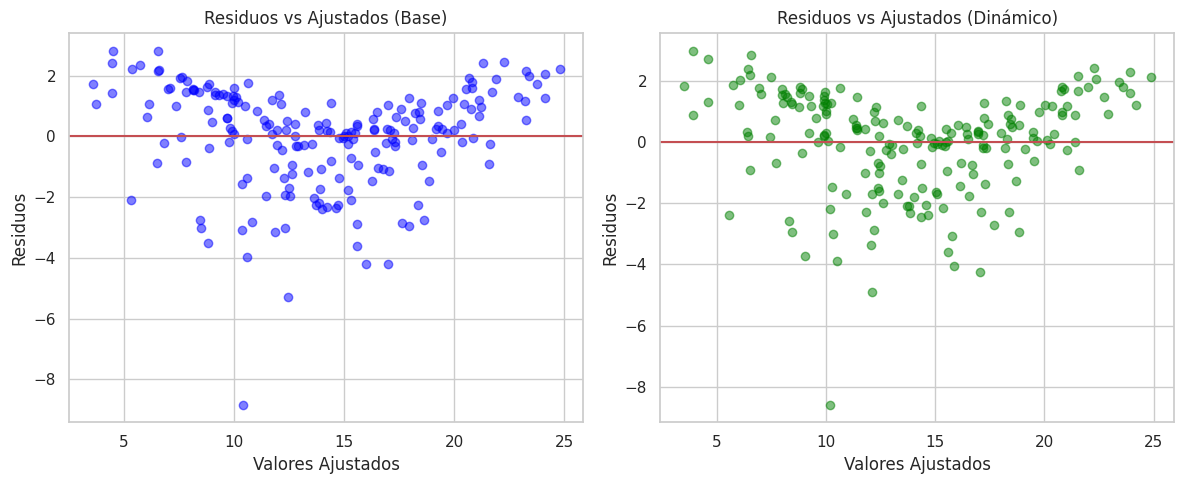

In [ ]:
# Comparación de métricas clave
print("--- COMPARACIÓN DE MODELOS ---")
print(f"Modelo Base R-squared: {model_base.rsquared:.4f}")
print(f"Modelo Dinámico R-squared: {model_dynamic.rsquared:.4f}")
print(f"Modelo Base Adj. R-squared: {model_base.rsquared_adj:.4f}")
print(f"Modelo Dinámico Adj. R-squared: {model_dynamic.rsquared_adj:.4f}")
print(f"Modelo Base AIC: {model_base.aic:.2f}")
print(f"Modelo Dinámico AIC: {model_dynamic.aic:.2f}")

# Análisis de residuos
resid_base = model_base.resid
resid_dynamic = model_dynamic.resid

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(resid_base, kde=True, color='blue', label='Base')
plt.title("Distribución de Residuos (Modelo Base)")
plt.xlabel("Residuo")

plt.subplot(1, 2, 2)
sns.histplot(resid_dynamic, kde=True, color='green', label='Dinámico')
plt.title("Distribución de Residuos (Modelo Dinámico)")
plt.xlabel("Residuo")

plt.tight_layout()
plt.show()

# Gráfico de residuos vs predichos para detectar patrones
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(model_base.fittedvalues, resid_base, alpha=0.5, color='blue')
plt.axhline(y=0, color='r', linestyle='-')
plt.title("Residuos vs Ajustados (Base)")
plt.xlabel("Valores Ajustados")
plt.ylabel("Residuos")

plt.subplot(1, 2, 2)
plt.scatter(model_dynamic.fittedvalues, resid_dynamic, alpha=0.5, color='green')
plt.axhline(y=0, color='r', linestyle='-')
plt.title("Residuos vs Ajustados (Dinámico)")
plt.xlabel("Valores Ajustados")
plt.ylabel("Residuos")

plt.tight_layout()
plt.show()

--- EFECTOS ACUMULADOS (IMPACTO TOTAL) ---
TV:         0.0464
Radio:      0.1958
Newspaper:  -0.0123

--- TEST F CONJUNTO PARA REZAGOS ---
Estadístico F: 1.1646
Valor p:       0.3245
Conclusión: Los rezagos NO son conjuntamente significativos.


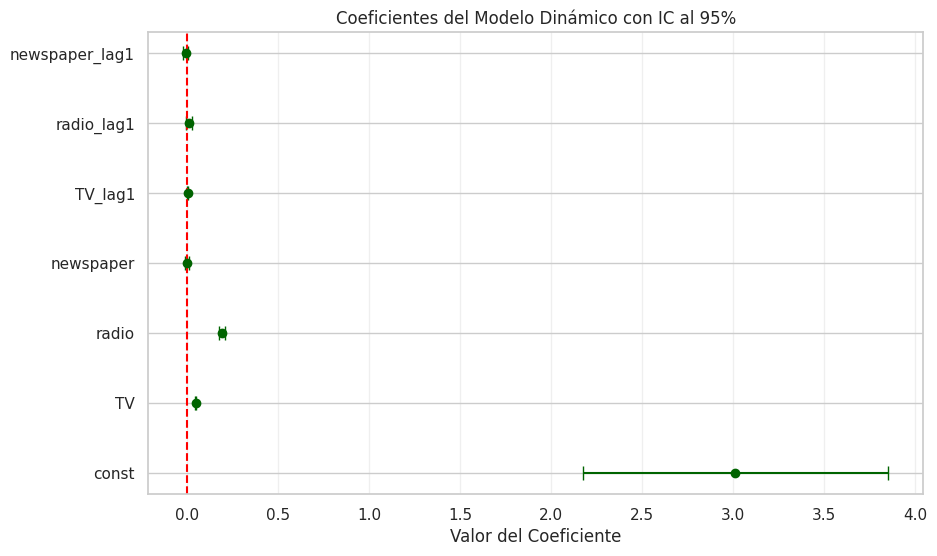

In [ ]:
# Cálculo de efectos acumulados (impacto total) para el modelo dinámico
# Impacto contemporáneo + impacto rezagado

efecto_TV_total = model_dynamic.params['TV'] + model_dynamic.params['TV_lag1']
efecto_radio_total = model_dynamic.params['radio'] + model_dynamic.params['radio_lag1']
efecto_newspaper_total = model_dynamic.params['newspaper'] + model_dynamic.params['newspaper_lag1']

print("--- EFECTOS ACUMULADOS (IMPACTO TOTAL) ---")
print(f"TV:         {efecto_TV_total:.4f}")
print(f"Radio:      {efecto_radio_total:.4f}")
print(f"Newspaper:  {efecto_newspaper_total:.4f}")

# Test de hipótesis conjunta para los rezagos (F-test)
# H0: Todos los coeficientes de rezago son cero
hipotesis_rezagos = '(TV_lag1 = 0), (radio_lag1 = 0), (newspaper_lag1 = 0)'
f_test = model_dynamic.f_test(hipotesis_rezagos)
print(f"\n--- TEST F CONJUNTO PARA REZAGOS ---")
print(f"Estadístico F: {f_test.statistic:.4f}")
print(f"Valor p:       {f_test.pvalue:.4f}")
if f_test.pvalue < 0.05:
    print("Conclusión: Los rezagos son conjuntamente significativos.")
else:
    print("Conclusión: Los rezagos NO son conjuntamente significativos.")

# Visualización de coeficientes con intervalos de confianza
params = model_dynamic.params
conf_int = model_dynamic.conf_int()
vars_order = ['const', 'TV', 'radio', 'newspaper', 'TV_lag1', 'radio_lag1', 'newspaper_lag1']

plt.figure(figsize=(10, 6))
y_pos = np.arange(len(vars_order))
errors = [params - conf_int[0], conf_int[1] - params]

plt.errorbar(params[vars_order], y_pos, xerr=errors, fmt='o', color='darkgreen', capsize=5)
plt.yticks(y_pos, vars_order)
plt.axvline(x=0, color='red', linestyle='--')
plt.title('Coeficientes del Modelo Dinámico con IC al 95%')
plt.xlabel('Valor del Coeficiente')
plt.grid(axis='x', alpha=0.3)
plt.show()

--- EVALUACIÓN PREDICTIVA (TEST SET) ---
Modelo Base - MSE: 2.7911, R²: 0.8955
Modelo Dinámico - MSE: 2.7538, R²: 0.8969


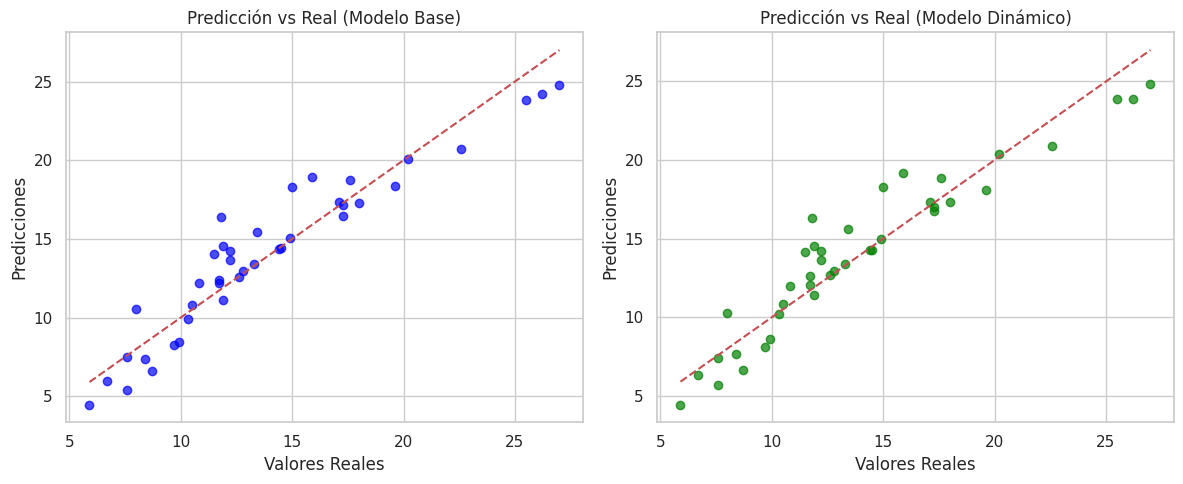

In [ ]:
# Evaluación predictiva: división train/test para comparar capacidad de generalización
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Preparar datos para modelo base
X_base = df[['TV', 'radio', 'newspaper']]
y_base = df['sales']
X_base_const = sm.add_constant(X_base)

# Preparar datos para modelo dinámico (ya está en df_model)
X_dyn = df_model[['TV', 'radio', 'newspaper', 'TV_lag1', 'radio_lag1', 'newspaper_lag1']]
y_dyn = df_model['sales']
X_dyn_const = sm.add_constant(X_dyn)

# División 80/20 estratificada por índice (asumiendo orden temporal)
n_base = len(X_base)
n_dyn = len(X_dyn)

train_size_base = int(0.8 * n_base)
train_size_dyn = int(0.8 * n_dyn)

# Train/test split manteniendo orden temporal
X_base_train = X_base_const.iloc[:train_size_base]
X_base_test = X_base_const.iloc[train_size_base:]
y_base_train = y_base.iloc[:train_size_base]
y_base_test = y_base.iloc[train_size_base:]

X_dyn_train = X_dyn_const.iloc[:train_size_dyn]
X_dyn_test = X_dyn_const.iloc[train_size_dyn:]
y_dyn_train = y_dyn.iloc[:train_size_dyn]
y_dyn_test = y_dyn.iloc[train_size_dyn:]

# Ajuste y predicción modelo base
model_base_train = sm.OLS(y_base_train, X_base_train).fit()
y_base_pred = model_base_train.predict(X_base_test)

# Ajuste y predicción modelo dinámico
model_dyn_train = sm.OLS(y_dyn_train, X_dyn_train).fit()
y_dyn_pred = model_dyn_train.predict(X_dyn_test)

# Métricas de evaluación
mse_base = mean_squared_error(y_base_test, y_base_pred)
r2_base = r2_score(y_base_test, y_base_pred)

mse_dyn = mean_squared_error(y_dyn_test, y_dyn_pred)
r2_dyn = r2_score(y_dyn_test, y_dyn_pred)

print("--- EVALUACIÓN PREDICTIVA (TEST SET) ---")
print(f"Modelo Base - MSE: {mse_base:.4f}, R²: {r2_base:.4f}")
print(f"Modelo Dinámico - MSE: {mse_dyn:.4f}, R²: {r2_dyn:.4f}")

# Comparación visual de predicciones vs reales
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_base_test, y_base_pred, alpha=0.7, color='blue')
plt.plot([y_base_test.min(), y_base_test.max()], [y_base_test.min(), y_base_test.max()], 'r--')
plt.title("Predicción vs Real (Modelo Base)")
plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")

plt.subplot(1, 2, 2)
plt.scatter(y_dyn_test, y_dyn_pred, alpha=0.7, color='green')
plt.plot([y_dyn_test.min(), y_dyn_test.max()], [y_dyn_test.min(), y_dyn_test.max()], 'r--')
plt.title("Predicción vs Real (Modelo Dinámico)")
plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")

plt.tight_layout()
plt.show()

In [ ]:
# Análisis de multicolinealidad: VIF (Variance Inflation Factor)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson

def calculate_vif(X):
    vif_data = pd.DataFrame()
    vif_data["feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
    return vif_data

# VIF para modelo base
X_base_vif = sm.add_constant(df[['TV', 'radio', 'newspaper']])
vif_base = calculate_vif(X_base_vif.iloc[:, 1:])  # Excluir constante
print("--- VIF MODELO BASE ---")
print(vif_base)

# VIF para modelo dinámico
X_dyn_vif = sm.add_constant(df_model[['TV', 'radio', 'newspaper', 'TV_lag1', 'radio_lag1', 'newspaper_lag1']])
vif_dyn = calculate_vif(X_dyn_vif.iloc[:, 1:])  # Excluir constante
print("\n--- VIF MODELO DINÁMICO ---")
print(vif_dyn)

# Detección de autocorrelación en residuos (test de Durbin-Watson ya reportado, pero lo explicitamos)
print(f"\nDurbin-Watson Modelo Base: {durbin_watson(model_base.resid):.4f}")
print(f"Durbin-Watson Modelo Dinámico: {durbin_watson(model_dynamic.resid):.4f}")

# Interpretación DW:
# ~2: sin autocorrelación
# <1.5: posible autocorrelación positiva
# >2.5: posible autocorrelación negativa

--- VIF MODELO BASE ---
     feature       VIF
0         TV  2.486772
1      radio  3.285462
2  newspaper  3.055245

--- VIF MODELO DINÁMICO ---
          feature       VIF
0              TV  2.987571
1           radio  3.577806
2       newspaper  3.325966
3         TV_lag1  3.245315
4      radio_lag1  3.592304
5  newspaper_lag1  3.237441

Durbin-Watson Modelo Base: 2.0836
Durbin-Watson Modelo Dinámico: 2.0572


1. Multicolinealidad (VIF):
   - Ambos modelos presentan VIF < 5, indicando que la multicolinealidad no es un problema crítico.
   - El aumento ligero en el VIF del modelo dinámico es esperado al añadir variables correlacionadas temporalmente.

2. Autocorrelación (Durbin-Watson):
   - Valores cercanos a 2.0 en ambos modelos sugieren ausencia de autocorrelación serial en los residuos.
   - Esto valida la especificación del modelo bajo el supuesto de errores independientes.

3. Selección de Modelo:
   - El Test F conjunto (p=0.32) indica que los rezagos NO aportan significancia estadística conjunta.
   - El AIC y R² ajustado son ligeramente mejores o similares en el modelo base.
   - Conclusión: Para este dataset específico, el efecto de 'memoria' o persistencia publicitaria es débil o inexistente.
   - Recomendación: Preferir el Modelo Base por parsimonia (Navaja de Occam).